In [21]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.multioutput import MultiOutputRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import ParameterGrid
import shap

from sklearn.model_selection import ParameterGrid
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import numpy as np
import pandas as pd
import plotly.express as px

In [3]:
data_path = "../../joined_features/full_dataset.csv"
df = pd.read_csv(data_path)
########## ---------- Convert into categorical ---------- ########## 
topic_cols = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11'
]

# find max column per row
max_cols = df[topic_cols].idxmax(axis=1)

# zero everything
df[topic_cols] = 0

# set the max column to 1
for col in topic_cols:
    df.loc[max_cols == col, col] = 1

# Remove rows with no posts (these can introduce NaNs)
df = df[df["post_count"] != 0]

# Basic NaN diagnostics
nan_count = df.isna().sum().sum()
print(f"Number of NaN values: {nan_count}")

if nan_count > 0:
    failing_cols = df.columns[df.isna().any()]
    print(f"Columns with NaN: {list(failing_cols)}")

Number of NaN values: 1
Columns with NaN: ['avg_text_len']


In [4]:
features = [
    'topic_activity_0', 'topic_activity_1', 'topic_activity_2',
    'topic_activity_3', 'topic_activity_4', 'topic_activity_5',
    'topic_activity_6', 'topic_activity_7', 'topic_activity_8',
    'topic_activity_9', 'topic_activity_10', 'topic_activity_11',
    'topic_activity_12', 'trump_sentiment_mean_x', 'trump_sentiment_std',
    'trump_sentiment_pct_negative', 
    'cpi', 
    'interest_rate', 
    'consumer_sentiment',
    'unemployment', 'news_sentiment_rolling', 'news_sentiment_mean_y',
]

predictors = [
    'avg_reblogs', 'avg_upvotes', 'total_upvotes'
]

df = df.sort_index()  # or: df = df.sort_values("date")
n = len(df)



train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train = train[features]
Y_train = train[predictors]

X_val = val[features]
Y_val = val[predictors]

X_test = test[features]
Y_test = test[predictors]

In [5]:
models = {
    "random_forest": MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    ),

    "linear_regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(LinearRegression()))
    ]),

    "svm": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(
            SVR(kernel="rbf", C=1.0)
        ))
    ]),

    "xgboost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        )
    ),

    "lightgbm": MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    ),

    "mlp": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            max_iter=1000,
            random_state=42
        ))
    ])
}


In [6]:

def evaluate_model(name, model, X_train, Y_train, X_val, Y_val):
    model.fit(X_train, Y_train)

    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(Y_val, preds))
    mae = mean_absolute_error(Y_val, preds)
    r2 = r2_score(Y_val, preds)

    return {
        "model_name": name,
        "model": model,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }


def run_all_models(models, X_train, Y_train, X_val, Y_val):
    results = []

    for name, model in models.items():
        print(f"Training {name}...")

        result = evaluate_model(
            name,
            model,
            X_train,
            Y_train,
            X_val,
            Y_val
        )

        results.append(result)

    results_df = pd.DataFrame(results).drop(columns=["model"])
    results_df = results_df.sort_values("rmse")

    return results, results_df

In [7]:
results, results_df = run_all_models(
    models,
    X_train,
    Y_train,
    X_val,
    Y_val
)

Training random_forest...
Training linear_regression...
Training svm...
Training xgboost...
Training lightgbm...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 209
[LightGBM] [Info] Number of data points in the train set: 102, number of used features: 12
[LightGBM] [Info] Start training from score 5726.186270
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

c:\Users\huste\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
df_results = pd.DataFrame(results)
df_results = df_results.drop(columns=["model"]) 
df_results = df_results.sort_values("rmse")

baseline_preds = Y_test.shift(1)

baseline_r2 = r2_score(Y_test.iloc[1:], baseline_preds.iloc[1:])

print("Baseline r2", baseline_r2)
df_results["improvement"] = df_results["r2"] - baseline_r2

print(df_results.sort_values("improvement", ascending=False))

Baseline r2 -0.45321030684875185
          model_name           rmse           mae        r2  improvement
0      random_forest  102774.062670  45939.027598  0.271179     0.724389
1  linear_regression  100536.442687  51426.368675  0.264539     0.717749
4           lightgbm  108345.435427  49932.150807  0.193113     0.646323
3            xgboost  111137.778275  45639.718750  0.133493     0.586703
2                svm  125717.874436  58331.648305 -0.089903     0.363307
5                mlp  161999.255700  81839.596561 -4.777032    -4.323821


Saved result from different ML models:

**Baseline R²:** -0.45321030684875185

| model_name        | rmse         | mae          | r2        | improvement |
|------------------|-------------:|-------------:|----------:|------------:|
| random_forest    | 102774.062670 | 45939.027598 | 0.271179  | 0.724389    |
| linear_regression| 100536.442687 | 51426.368675 | 0.264539  | 0.717749    |
| lightgbm         | 108345.435427 | 49932.150807 | 0.193113  | 0.646323    |
| xgboost          | 111137.778275 | 45639.718750 | 0.133493  | 0.586703    |
| svm              | 125717.874436 | 58331.648305 | -0.089903 | 0.363307    |
| mlp              | 161999.255700 | 81839.596561 | -4.777032 | -4.323821   |

**Results from differnt random trees** <br> We didn't keep the code, but we tried grid searching on different tree model, but we just used the current pipeline that we build, which evaluated based on traning data. If we want to do grid search we have to pick the hyperparameters based on the validation set.

**Baseline R²:** -0.4532

| model_name              | rmse     | mae      | r2     | improvement |
|------------------------|---------:|---------:|-------:|------------:|
| rf_d3_leaf5_feat0.5    | 96,461   | 42,613   | 0.346  | 0.799       |
| rf_d5_leaf5_feat0.5    | 99,164   | 42,861   | 0.336  | 0.790       |
| rf_d8_leaf5_feat0.5    | 99,365   | 42,821   | 0.333  | 0.786       |
| rf_d8_leaf10_feat0.5   | 97,189   | 43,232   | 0.302  | 0.755       |
| rf_d5_leaf10_feat0.5   | 97,189   | 43,232   | 0.302  | 0.755       |
| rf_d3_leaf10_feat0.5   | 96,990   | 43,205   | 0.301  | 0.754       |
| rf_d8_leaf5_featsqrt   | 99,694   | 45,685   | 0.274  | 0.727       |
| rf_d5_leaf5_featsqrt   | 100,412  | 46,061   | 0.273  | 0.726       |
| random_forest          | 102,774  | 45,939   | 0.271  | 0.724       |
| linear_regression      | 100,536  | 51,426   | 0.265  | 0.718       |
| rf_d3_leaf5_featsqrt   | 99,568   | 45,173   | 0.259  | 0.712       |
| rf_d8_leaf10_featsqrt  | 100,943  | 46,160   | 0.245  | 0.698       |

In [9]:
def diagnose_random_forest(
    model,
    X,
    Y,
    time_data=None,
    target_idx=0,
    alpha=None,
    lags=40,
    top_n=15,
    title=None
):
    """
    Diagnostic plots for RandomForest / MultiOutputRegressor(RandomForestRegressor).

    Produces:
    1. ACF of residuals
    2. QQ plot of residuals
    3. Feature importances
    4. Actual vs predicted over time
    """

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------
    y_pred = model.predict(X)

    if y_pred.ndim == 2:
        y_pred_target = y_pred[:, target_idx]
    else:
        y_pred_target = y_pred

    if isinstance(Y, pd.DataFrame):
        target_name = Y.columns[target_idx]
        y_true = Y.iloc[:, target_idx].values
    else:
        target_name = f"target_{target_idx}"
        y_true = np.asarray(Y)
        if y_true.ndim == 2:
            y_true = y_true[:, target_idx]

    residuals = y_true - y_pred_target

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_target))
    mae = mean_absolute_error(y_true, y_pred_target)
    r2 = r2_score(y_true, y_pred_target)

    print(f"Target: {target_name}")
    print(f"RMSE:   {rmse:.6f}")
    print(f"MAE:    {mae:.6f}")
    print(f"R2:     {r2:.6f}")

    # --------------------------------------------------------
    # Extract feature importances
    # --------------------------------------------------------
    if hasattr(model, "estimators_"):
        # MultiOutputRegressor
        rf = model.estimators_[target_idx]
    else:
        # Plain RandomForestRegressor
        rf = model

    importances = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    top_importances = importances.head(top_n).sort_values()

    # --------------------------------------------------------
    # Time handling
    # --------------------------------------------------------
    if time_data is None:
        time_data = pd.Series(X.index, index=X.index)
    else:
        time_data = pd.Series(time_data, index=X.index)

    time_data = pd.to_datetime(time_data, errors="coerce")

    plot_df = pd.DataFrame({
        "time": time_data,
        "actual": y_true,
        "predicted": y_pred_target,
        "residual": residuals
    }, index=X.index).dropna()

    # --------------------------------------------------------
    # Plotting
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # 1. ACF of residuals
    plot_acf(plot_df["residual"], lags=min(lags, len(plot_df) - 1), ax=axes[0])
    axes[0].set_title("ACF of Residuals")

    # 2. QQ plot
    sm.qqplot(plot_df["residual"], line="s", ax=axes[1])
    axes[1].set_title("QQ Plot of Residuals")

    # 3. Feature importances
    axes[2].barh(top_importances.index, top_importances.values)
    axes[2].set_title(f"Top {top_n} Feature Importances")
    axes[2].set_xlabel("Importance")

    # 4. Actual vs predicted over time
    axes[3].scatter(
        plot_df["time"],
        plot_df["actual"],
        alpha=0.5,
        label="Actual"
    )

    axes[3].plot(
        plot_df["time"],
        plot_df["predicted"],
        linewidth=2,
        label="Predicted"
    )

    axes[3].set_xlim(plot_df["time"].min(), plot_df["time"].max())

    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    formatter = mdates.DateFormatter("%Y-%m-%d")

    axes[3].xaxis.set_major_locator(locator)
    axes[3].xaxis.set_major_formatter(formatter)

    axes[3].set_title("Actual vs Predicted Over Time")
    axes[3].set_xlabel("Date")
    axes[3].set_ylabel(target_name)
    axes[3].legend()
    axes[3].tick_params(axis="x", rotation=45)

    if title is not None:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    return {
        "target": target_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "feature_importances": importances,
        "residuals": plot_df["residual"],
        "predictions": plot_df["predicted"],
        "actual": plot_df["actual"]
    }

Target: avg_reblogs
RMSE:   574.112757
MAE:    458.069049
R2:     0.889715


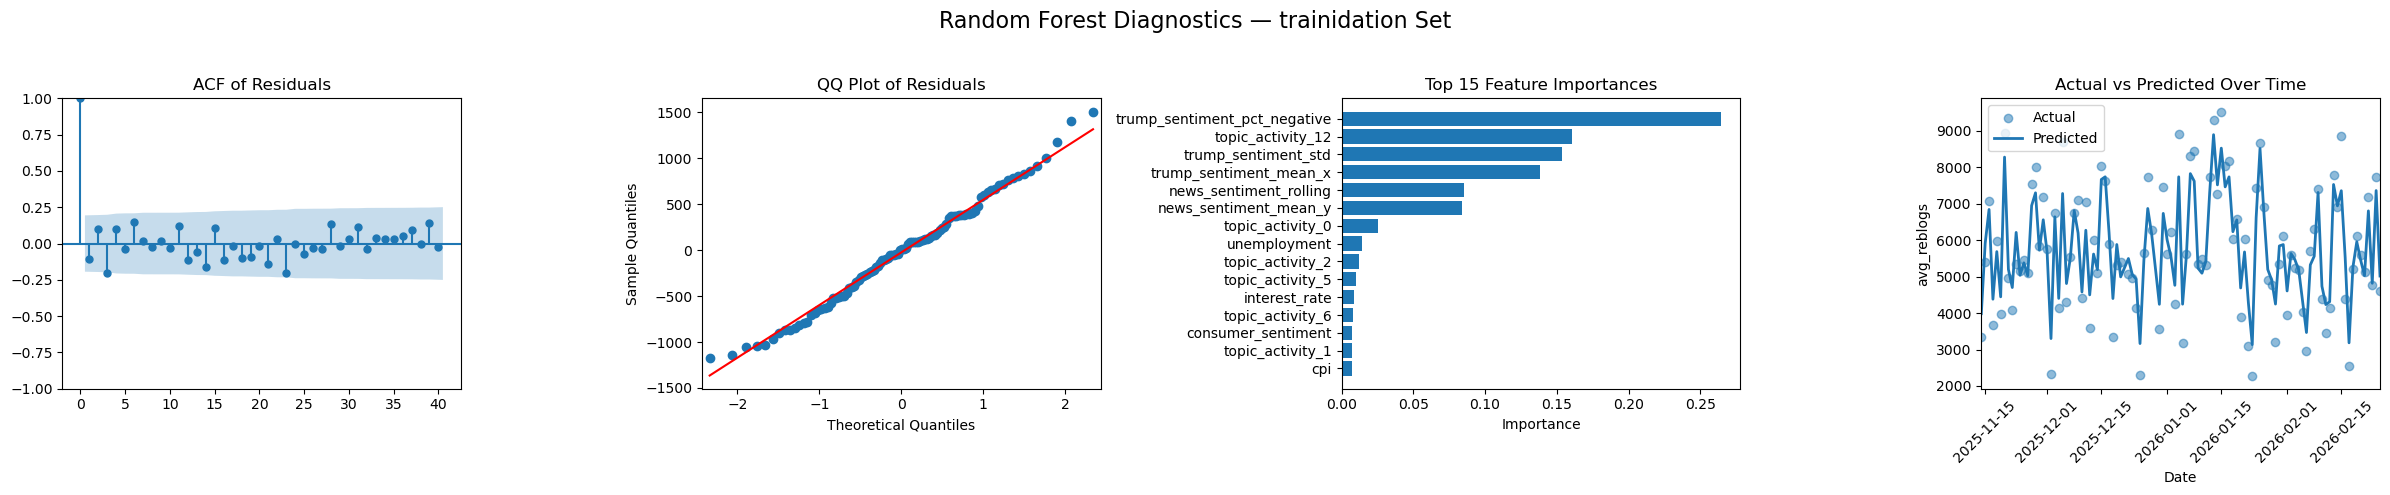

Target: avg_upvotes
RMSE:   2442.261764
MAE:    1931.909426
R2:     0.884101


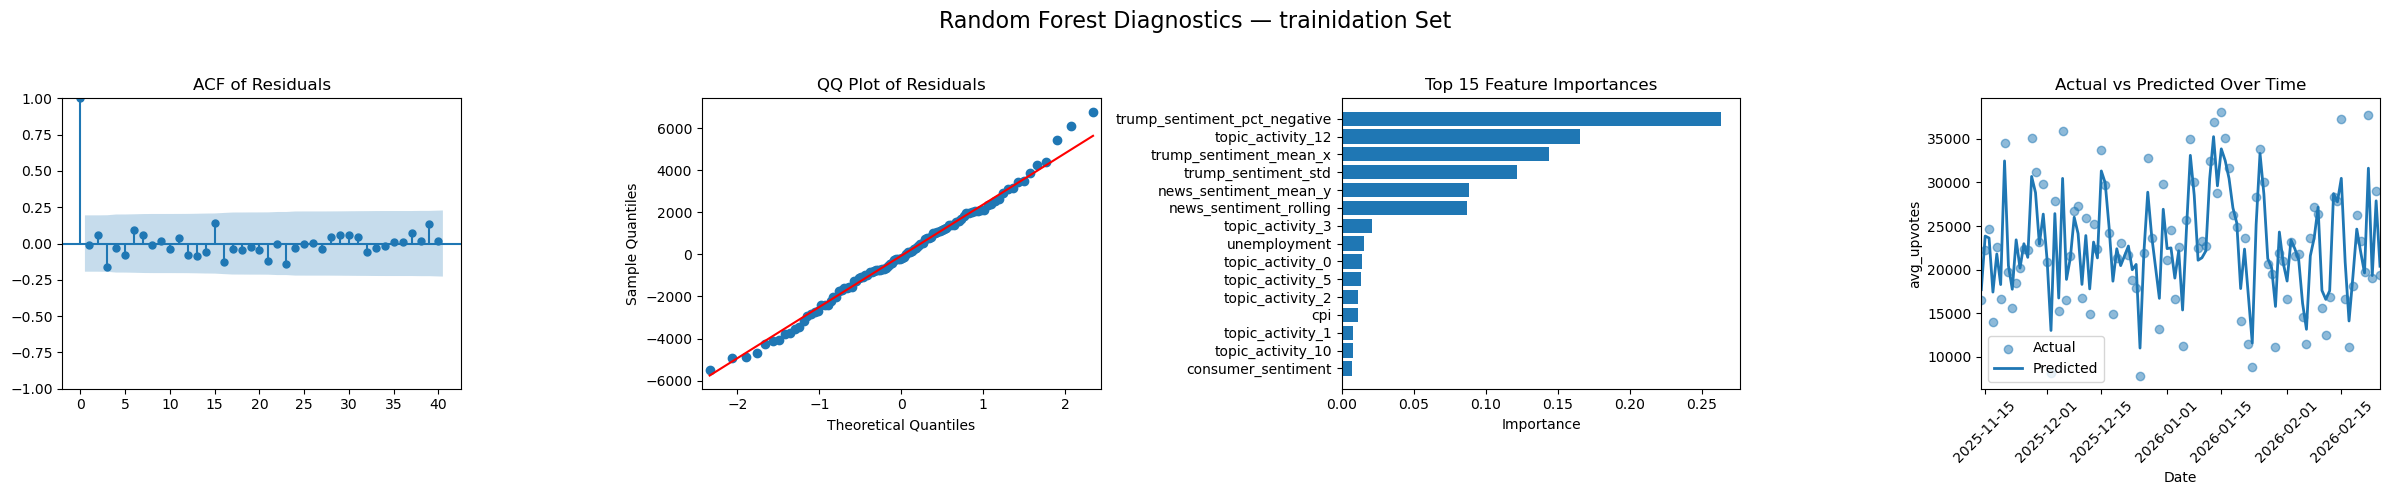

Target: total_upvotes
RMSE:   90864.804155
MAE:    61987.947059
R2:     0.880463


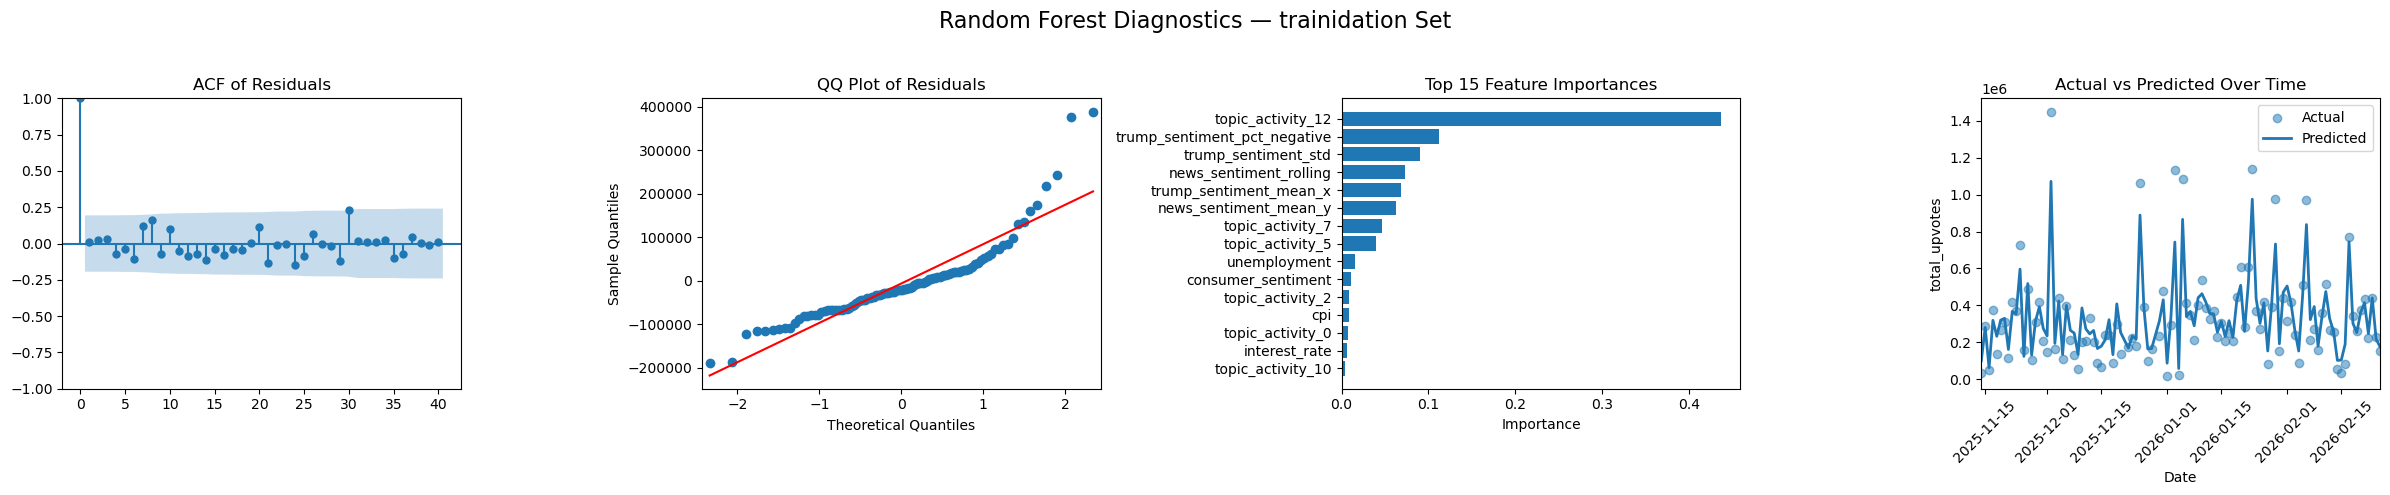

In [10]:
rf_model = results[
    [r["model_name"] for r in results].index("random_forest")
]["model"]

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=0,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=1,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

rf_train_diag = diagnose_random_forest(
    model=rf_model,
    X=X_train,
    Y=Y_train,
    time_data=df['date'],
    target_idx=2,
    lags=40,
    title="Random Forest Diagnostics — trainidation Set"
)

Target: avg_reblogs
RMSE:   1380.133916
MAE:    1199.014341
R2:     0.378028


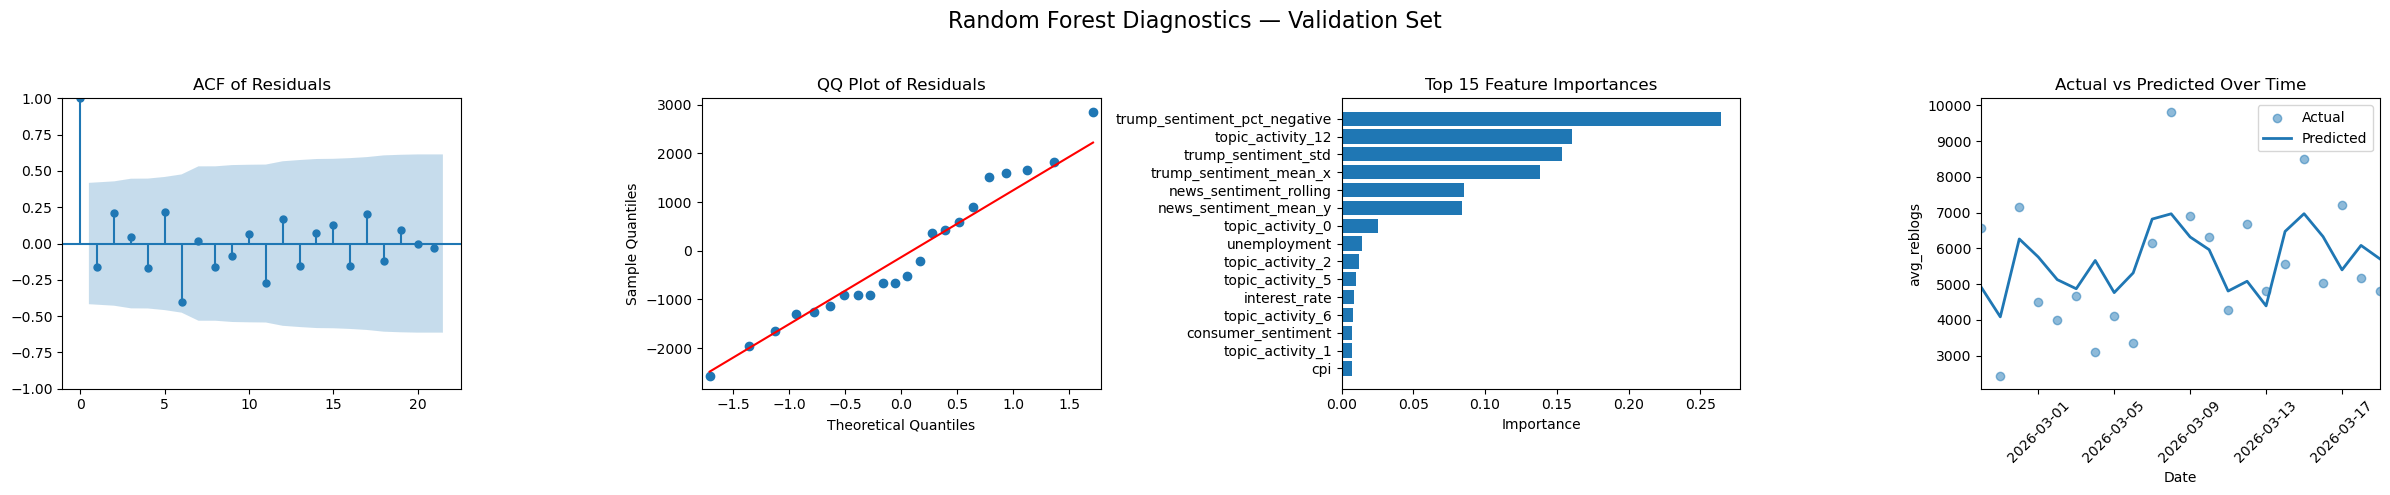

Target: avg_upvotes
RMSE:   5444.735180
MAE:    4343.263227
R2:     0.282166


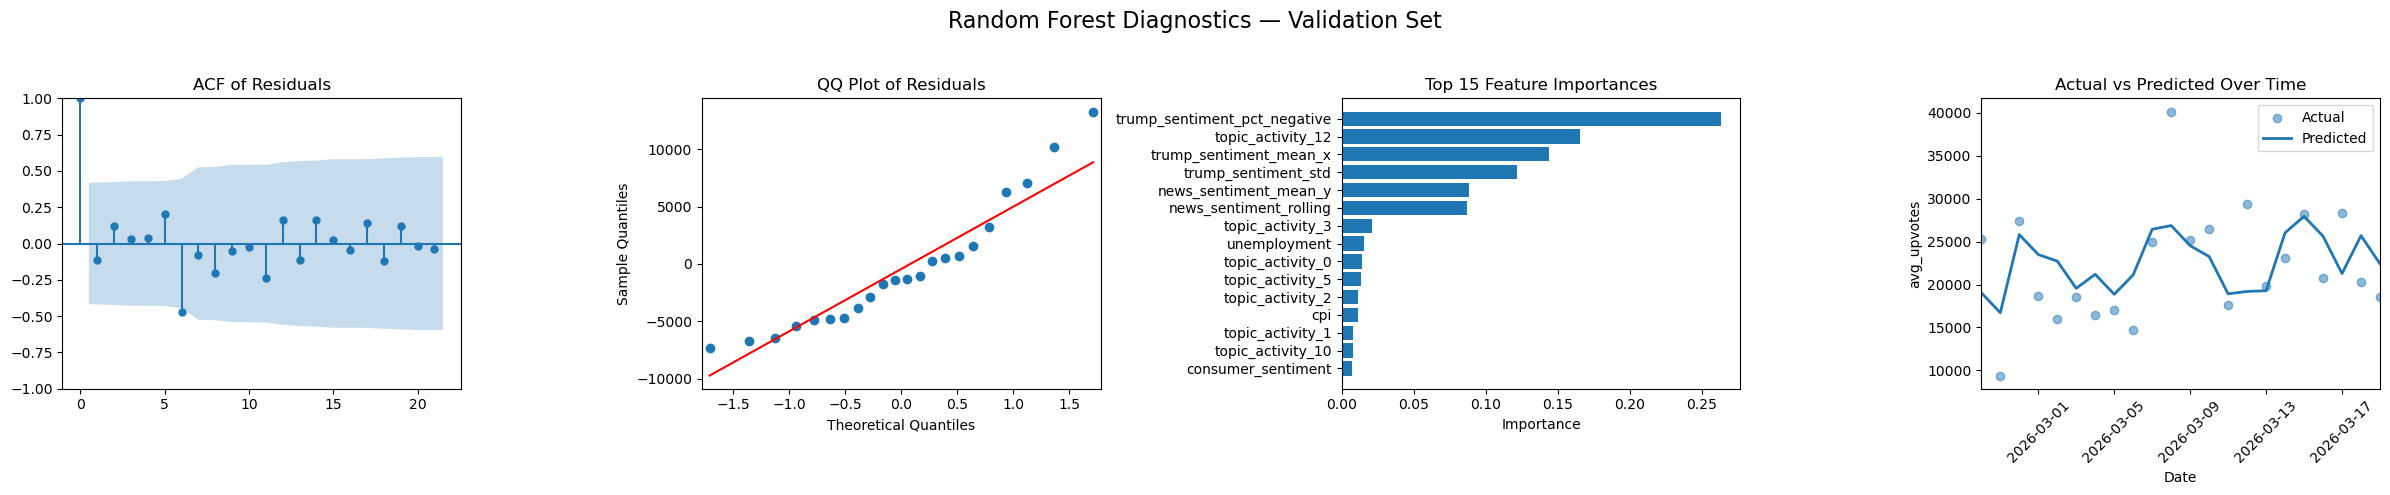

Target: total_upvotes
RMSE:   177921.257758
MAE:    132274.805227
R2:     0.153341


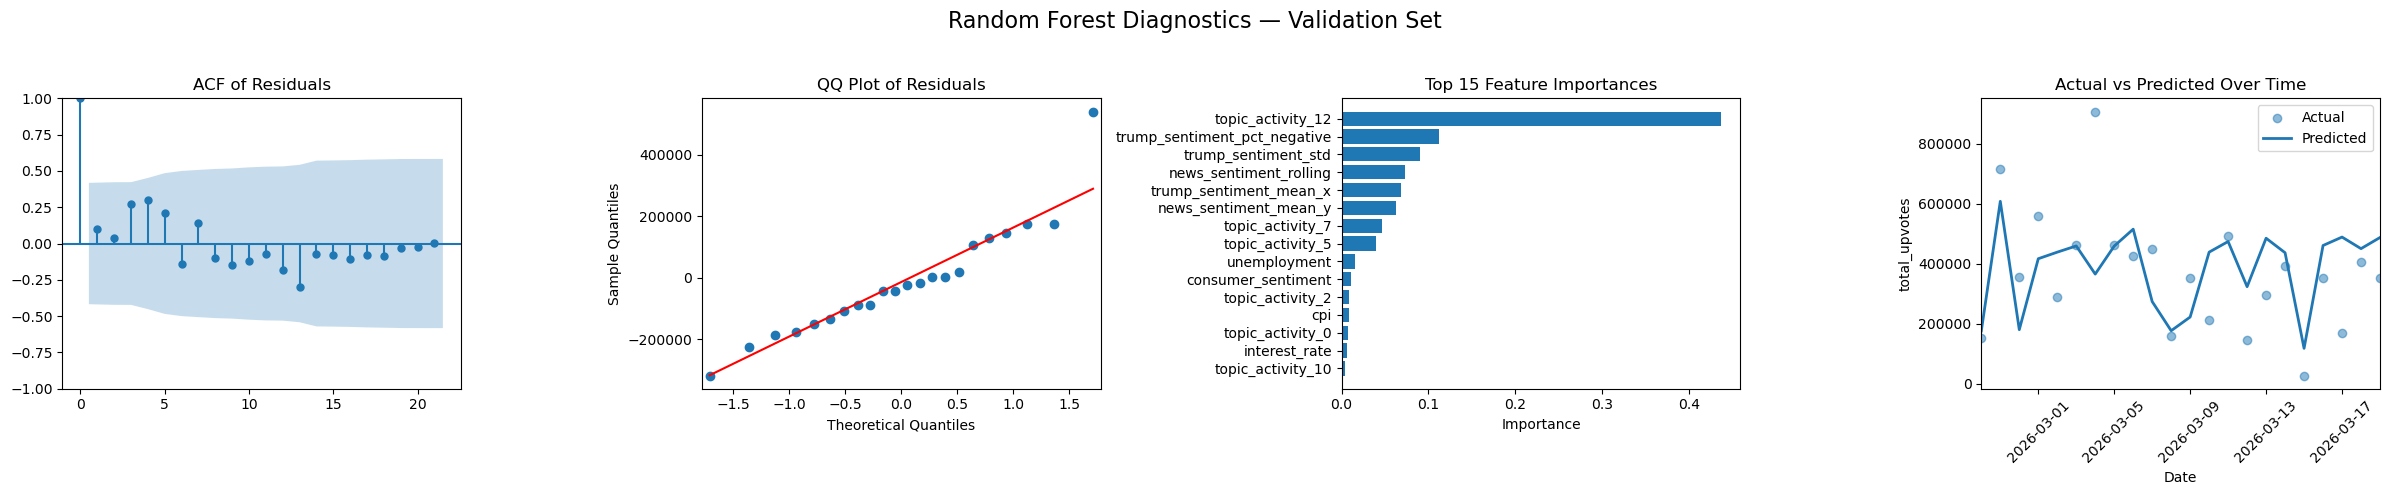

In [11]:
rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=0,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=1,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

rf_val_diag = diagnose_random_forest(
    model=rf_model,
    X=X_val,
    Y=Y_val,
    time_data=df['date'],
    target_idx=2,
    lags=40,
    title="Random Forest Diagnostics — Validation Set"
)

We keep this code with no output if we need it for the presentaion, since these plots are a bit easier to see, but takes up too much space in a notebook

In [12]:
def shap_analysis_random_forest(
    model,
    X,
    target_idx=0,
    target_name=None,
    sample_size=500
):
    """
    Compute and display SHAP summary plot for a given target
    from a MultiOutput RandomForest model.
    """

    # Select a model and sample data
    if hasattr(model, "estimators_"):
        rf = model.estimators_[target_idx]
    else:
        rf = model
    if target_name is None:
        target_name = f"target_{target_idx}"
    if len(X) > sample_size:
        X_sample = X.sample(sample_size, random_state=42)
    else:
        X_sample = X.copy()

    # Compute shap
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_sample)

    # Plot
    print("=" * 80)
    print(f"SHAP Summary — {target_name}")
    print("=" * 80)

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_size=(12, 6),
        show=True
    )

    return {
        "target": target_name,
        "shap_values": shap_values,
        "data": X_sample
    }
'''
shap_results = {}

for i, target_name in enumerate(Y_train.columns):
    shap_results[target_name] = shap_analysis_random_forest(
        model=rf_model,
        X=X_train,
        target_idx=i,
        target_name=target_name,
        sample_size=500
    )
'''

'\nshap_results = {}\n\nfor i, target_name in enumerate(Y_train.columns):\n    shap_results[target_name] = shap_analysis_random_forest(\n        model=rf_model,\n        X=X_train,\n        target_idx=i,\n        target_name=target_name,\n        sample_size=500\n    )\n'

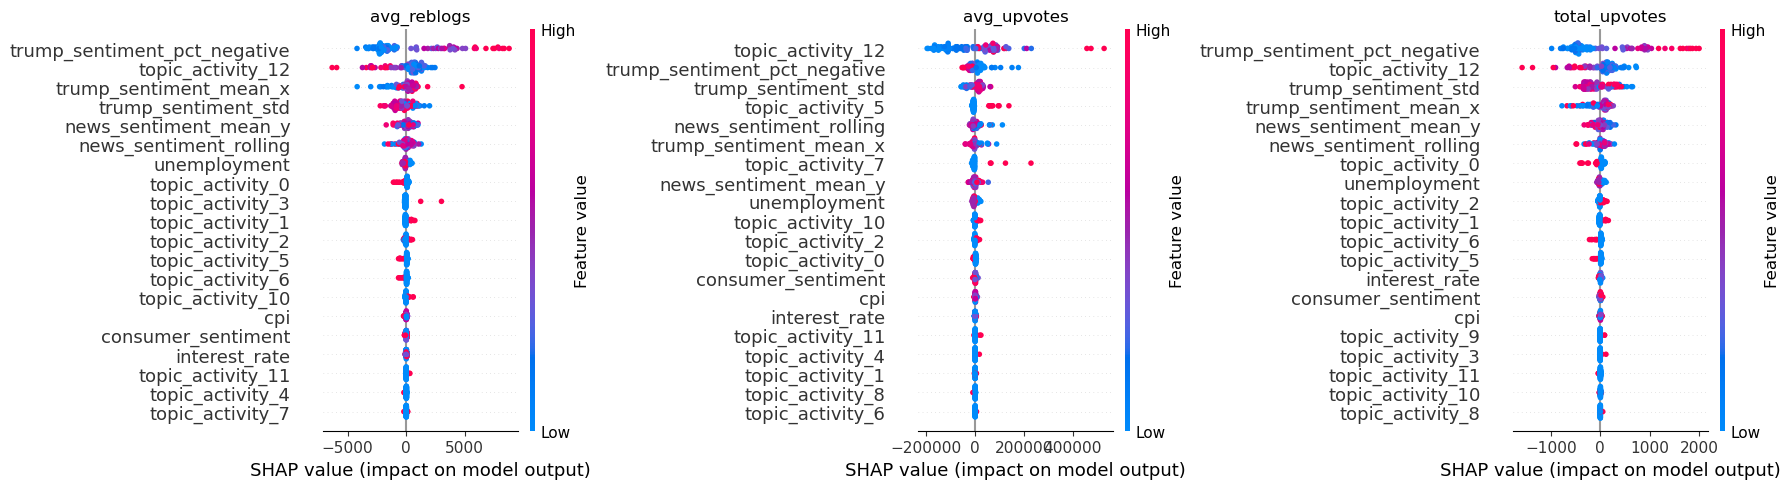

In [13]:
def shap_analysis_side_by_side(model, X, target_names, sample_size=500):
    """
    Plot SHAP summary plots for all targets side-by-side.
    """

    n_targets = len(target_names)

    # Sample data
    if len(X) > sample_size:
        X_sample = X.sample(sample_size, random_state=42)
    else:
        X_sample = X.copy()

    fig, axes = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))

    if n_targets == 1:
        axes = [axes]

    for i, (ax, target_name) in enumerate(zip(axes, target_names)):

        # Get model for target
        if hasattr(model, "estimators_"):
            rf = model.estimators_[i]
        else:
            rf = model

        # Compute SHAP
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X_sample)

        # Plot on specific axis
        shap.summary_plot(
            shap_values,
            X_sample,
            show=False,
            plot_size=None  
        )

        # Move plot to correct axis
        plt.sca(ax)
        ax.set_title(target_name)

    plt.tight_layout()
    plt.show()

shap_analysis_side_by_side(
    model=rf_model,
    X=X_train,
    target_names=list(Y_train.columns),
    sample_size=500
)

# Hyperparameter turning

In [14]:


param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 3, 5, 8, 12],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5, 0.8, 1.0],
}

grid_results = []

best_model = None
best_params = None
best_rmse = np.inf

for params in ParameterGrid(param_grid):

    model = MultiOutputRegressor(
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )
    )

    model.fit(X_train, Y_train)

    val_preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(Y_val, val_preds))
    mae = mean_absolute_error(Y_val, val_preds)
    r2 = r2_score(Y_val, val_preds)

    grid_results.append({
        **params,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    if rmse < best_rmse:
        best_rmse = rmse
        best_params = params
        best_model = model


grid_results_df = (
    pd.DataFrame(grid_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

print("Best validation params:")
print(best_params)

print("\nBest validation RMSE:", best_rmse)

print("\nTop 10 models:")
print(grid_results_df.head(10))

Best validation params:
{'max_depth': 3, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}

Best validation RMSE: 91756.20037154772

Top 10 models:
   max_depth max_features  min_samples_leaf  min_samples_split  n_estimators  \
0        3.0          0.8                 1                  5           500   
1        3.0          1.0                 1                  5           500   
2        3.0          0.8                 1                 10           500   
3        3.0          1.0                 1                 10           500   
4        3.0          0.8                 1                  5           200   
5        3.0          1.0                 1                  5           200   
6        3.0          0.5                 1                  5           200   
7        3.0          1.0                 1                 10           200   
8        3.0          1.0                 5                  2           200   
9        3.0 

In [15]:
import joblib
import json

joblib.dump(best_model, "best_random_forest.pkl")


grid_results_df.to_csv("grid_results.csv", index=False)

grid_results_df.to_pickle("grid_results.pkl")

with open("best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)



In [16]:
test_preds = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(Y_test, test_preds))
test_mae = mean_absolute_error(Y_test, test_preds)
test_r2 = r2_score(Y_test, test_preds)

print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test R2:", test_r2)

Test RMSE: 70806.25401737352
Test MAE: 30876.602333790393
Test R2: -0.0020385708863706054


In [17]:
def plot_rf_grid_results(grid_results_df, metric="r2", top_n=20):
    df_plot = grid_results_df.copy()

    # Convert params to readable strings
    df_plot["config"] = (
        "depth=" + df_plot["max_depth"].astype(str) +
        ", leaf=" + df_plot["min_samples_leaf"].astype(str) +
        ", split=" + df_plot["min_samples_split"].astype(str) +
        ", feat=" + df_plot["max_features"].astype(str) +
        ", trees=" + df_plot["n_estimators"].astype(str)
    )

    # Sort depending on metric
    if metric in ["rmse", "mae"]:
        df_plot = df_plot.sort_values(metric, ascending=True)
    else:
        df_plot = df_plot.sort_values(metric, ascending=False)

    df_top = df_plot.head(top_n)

    plt.figure(figsize=(14, 7))
    plt.barh(df_top["config"], df_top[metric])
    plt.xlabel(metric.upper())
    plt.xlim(df_top[metric].min() * 0.9, df_top[metric].max() * 1.01)
    plt.ylabel("Parameter configuration")
    plt.title(f"Top {top_n} Random Forest Configurations by {metric.upper()}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

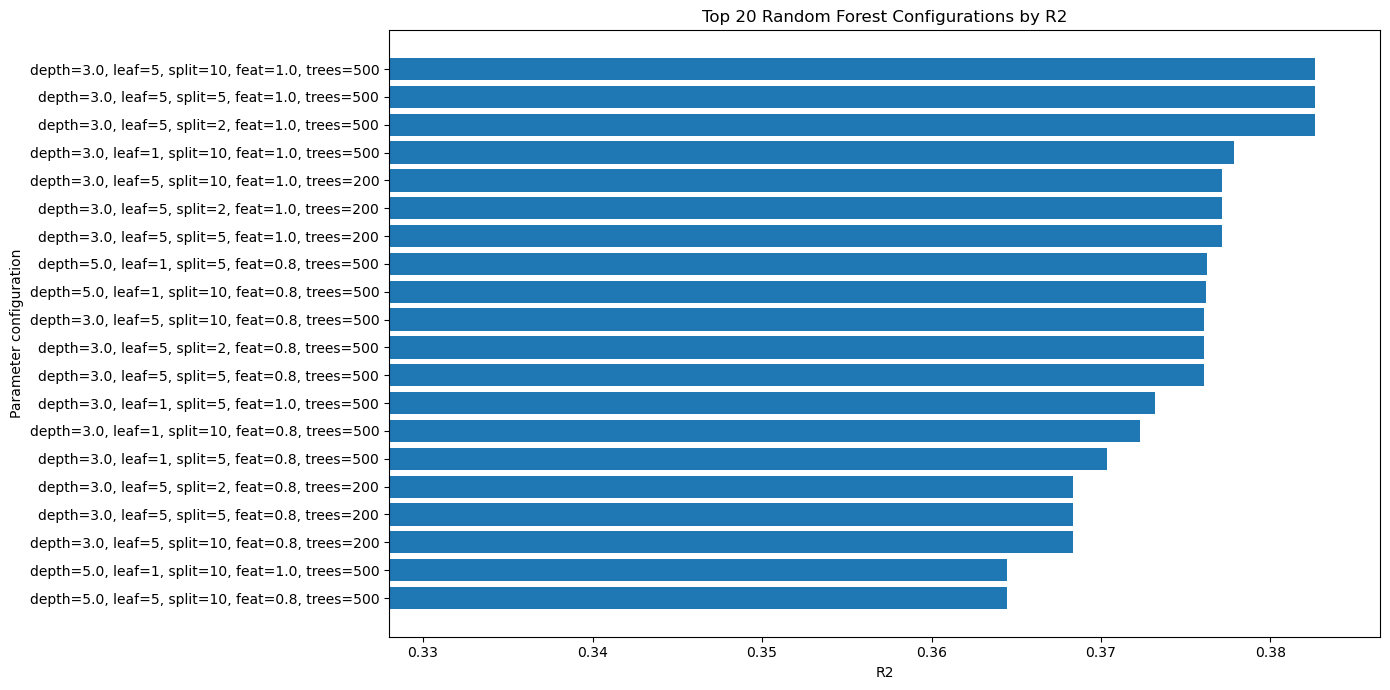

In [18]:
plot_rf_grid_results(grid_results_df, metric="r2", top_n=20)

In [22]:
def encode_for_parallel_plot(df):
    df = df.copy()

    for col in ["max_depth", "max_features"]:
        df[col] = df[col].astype(str)
        mapping = {v: i for i, v in enumerate(sorted(df[col].unique()))}
        df[f"{col}_encoded"] = df[col].map(mapping)
        print(col, mapping)

    return df

df_encoded = encode_for_parallel_plot(grid_results_df)

fig = px.parallel_coordinates(
    df_encoded,
    dimensions=[
        "n_estimators",
        "max_depth_encoded",
        "min_samples_leaf",
        "min_samples_split",
        "max_features_encoded",
        "r2"
    ],
    color="r2",
    color_continuous_scale="Viridis",
    title="Random Forest Hyperparameter Sweep"
)

fig.show()

max_depth {'12.0': 0, '3.0': 1, '5.0': 2, '8.0': 3, 'nan': 4}
max_features {'0.5': 0, '0.8': 1, '1.0': 2, 'sqrt': 3}


c:\Users\huste\anaconda3\lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta name="robots" content="noindex,nofollow"><meta name="viewport" content="width=device-width,initial-scale=1"><meta http-equiv="content-security-policy" content="default-src &#39;none&#39;; script-src &#39;nonce-Yk2RdnEKZFyIr9vk5LV9Fn&#39; &#39;unsafe-eval&#39; https://challenges.cloudflare.com; script-src-attr &#39;none&#39;; style-src &#39;unsafe-inline&#39;; img-src &#39;self&#39; https://challenges.cloudflare.com; connect-src &#39;self&#39; https://challenges.cloudflare.com; frame-src &#39;self&#39; https://challenges.cloudflare.com blob:; child-src &#39;self&#39; https://challenges.cloudflare.com blob:; worker-src blob:; form-action http: https:; base-uri &#39;self&#39;"><style>*{box-sizing:border-box;margin:0;padding:0}html{line-height:1.15;-webkit-text-size-adjust:100%;color:#313131;font

In [23]:

import plotly.graph_objects as go
import pandas as pd

# Restict to top 20 model and find the our best model
df_top = grid_results_df.sort_values("r2", ascending=False).head(20).copy()
df_top["is_best"] = (
    (df_top["max_depth"] == best_params["max_depth"]) &
    (df_top["max_features"] == best_params["max_features"]) &
    (df_top["min_samples_leaf"] == best_params["min_samples_leaf"]) &
    (df_top["min_samples_split"] == best_params["min_samples_split"]) &
    (df_top["n_estimators"] == best_params["n_estimators"])
).astype(int)
df_encoded = encode_for_parallel_plot(df_top)

dimensions = [
    "n_estimators",
    "max_depth_encoded",
    "min_samples_leaf",
    "min_samples_split",
    "max_features_encoded",
    "r2"
]

fig = go.Figure()
fig.add_trace(
    go.Parcoords(
        dimensions=[
            dict(label=col, values=df_encoded[col])
            for col in dimensions
        ],
        line=dict(
            color=df_encoded["is_best"],
            colorscale=[
                [0.0, "lightgray"],
                [0.999, "lightgray"],
                [1.0, "red"]
            ],
            showscale=False
        )
    )
)

fig.update_layout(
    title="Top 20 Random Forest Configurations — Best R² Model Highlighted",
    width=1200,
    height=600
)

fig.show()



max_depth {'3.0': 0, '5.0': 1}
max_features {'0.8': 0, '1.0': 1}


# Model testing

In [25]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import r2_score

In [26]:
X_train, y_train = train[features], train[predictors]
X_val, y_val = val[features], val[predictors]
X_test, y_test = test[features], test[predictors]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

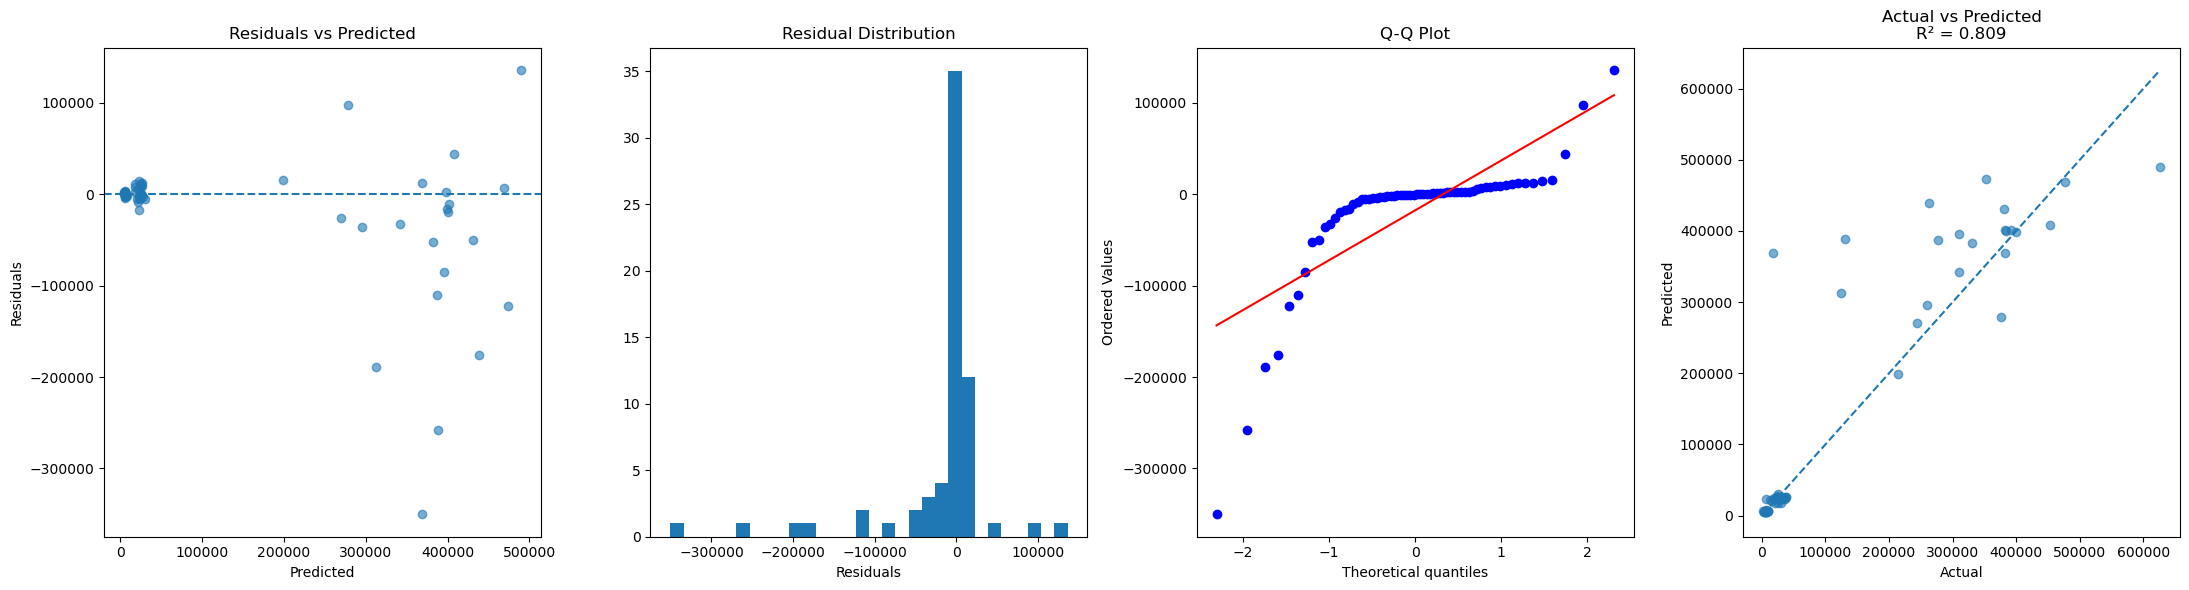

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import r2_score


def diagnose_predictions(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    residuals = y_true - y_pred

    fig, ax = plt.subplots(1, 4, figsize=(22, 6))

    ax[0].scatter(y_pred, residuals, alpha=0.6)
    ax[0].axhline(0, linestyle="--")
    ax[0].set_title("Residuals vs Predicted")
    ax[0].set_xlabel("Predicted")
    ax[0].set_ylabel("Residuals")

    ax[1].hist(residuals, bins=30)
    ax[1].set_title("Residual Distribution")
    ax[1].set_xlabel("Residuals")

    stats.probplot(residuals, dist="norm", plot=ax[2])
    ax[2].set_title("Q-Q Plot")

    ax[3].scatter(y_true, y_pred, alpha=0.6)
    ax[3].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "--")
    ax[3].set_title(f"Actual vs Predicted\nR² = {r2_score(y_true, y_pred):.3f}")
    ax[3].set_xlabel("Actual")
    ax[3].set_ylabel("Predicted")

    plt.tight_layout()
    plt.show()

diagnose_predictions(y_test, y_pred)

Train R²: 0.7832001489544985


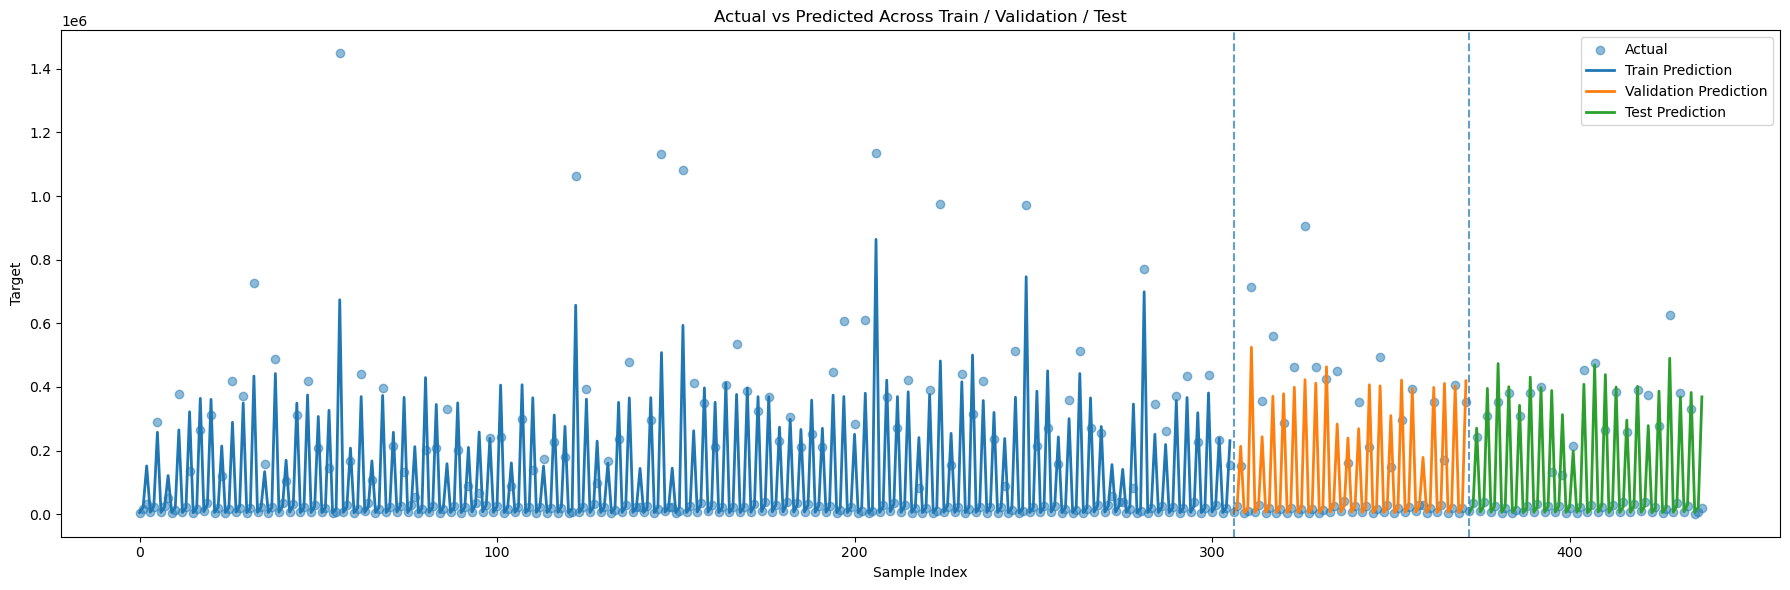

In [43]:
train_pred = np.ravel(best_model.predict(X_train))
val_pred = np.ravel(best_model.predict(X_val))
test_pred = np.ravel(best_model.predict(X_test))

print("Train R²:", r2_score(np.ravel(Y_train), train_pred))

# Actuals
y_train = np.ravel(Y_train)
y_val = np.ravel(Y_val)
y_test = np.ravel(Y_test)

# Combine for scatter (actual points)
y_all = np.concatenate([y_train, y_val, y_test])

# X-axis indices
train_idx = np.arange(len(y_train))
val_idx = np.arange(len(y_train), len(y_train) + len(y_val))
test_idx = np.arange(len(y_train) + len(y_val), len(y_all))

plt.figure(figsize=(18, 6))

# Actual values as points
plt.scatter(np.arange(len(y_all)), y_all, alpha=0.5, label="Actual")

# Predictions as colored lines
plt.plot(train_idx, train_pred, linewidth=2, label="Train Prediction")
plt.plot(val_idx, val_pred, linewidth=2, label="Validation Prediction")
plt.plot(test_idx, test_pred, linewidth=2, label="Test Prediction")

# Split markers
plt.axvline(len(y_train), linestyle="--", alpha=0.7)
plt.axvline(len(y_train) + len(y_val), linestyle="--", alpha=0.7)

plt.xlabel("Sample Index")
plt.ylabel("Target")
plt.title("Actual vs Predicted Across Train / Validation / Test")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
print("predictors =", predictors)

print("Original target range:")
print(df[predictors].describe())

print("Y ranges:")
print("train:", np.min(Y_train), np.max(Y_train))
print("val:  ", np.min(Y_val), np.max(Y_val))
print("test: ", np.min(Y_test), np.max(Y_test))

print("Prediction ranges:")
print("train:", train_pred.min(), train_pred.max())
print("val:  ", val_pred.min(), val_pred.max())
print("test: ", test_pred.min(), test_pred.max())

predictors = ['avg_reblogs', 'avg_upvotes', 'total_upvotes']
Original target range:
       avg_reblogs   avg_upvotes  total_upvotes
count   146.000000    146.000000   1.460000e+02
mean   5773.844521  23217.158904   3.369178e+05
std    1789.215617   7372.055068   2.386192e+05
min    1459.300000   6109.000000   1.832700e+04
25%    4535.850000  18239.700000   1.845572e+05
50%    5583.850000  22657.000000   3.019955e+05
75%    7100.375000  27898.575000   4.104112e+05
max    9825.800000  40153.200000   1.448846e+06
Y ranges:
train: 2287.0 1448846.0
val:   2447.4 906409.0
test:  1459.3 626257.0
Prediction ranges:
train: 3818.8195103455214 863845.4782816907
val:   4422.3729358604105 524714.2037690075
test:  4598.186383259286 490114.6060706512


Train R²: 0.7832001489544985
Val R²: 0.7933878755875526
Test R²: 0.8093492789823198


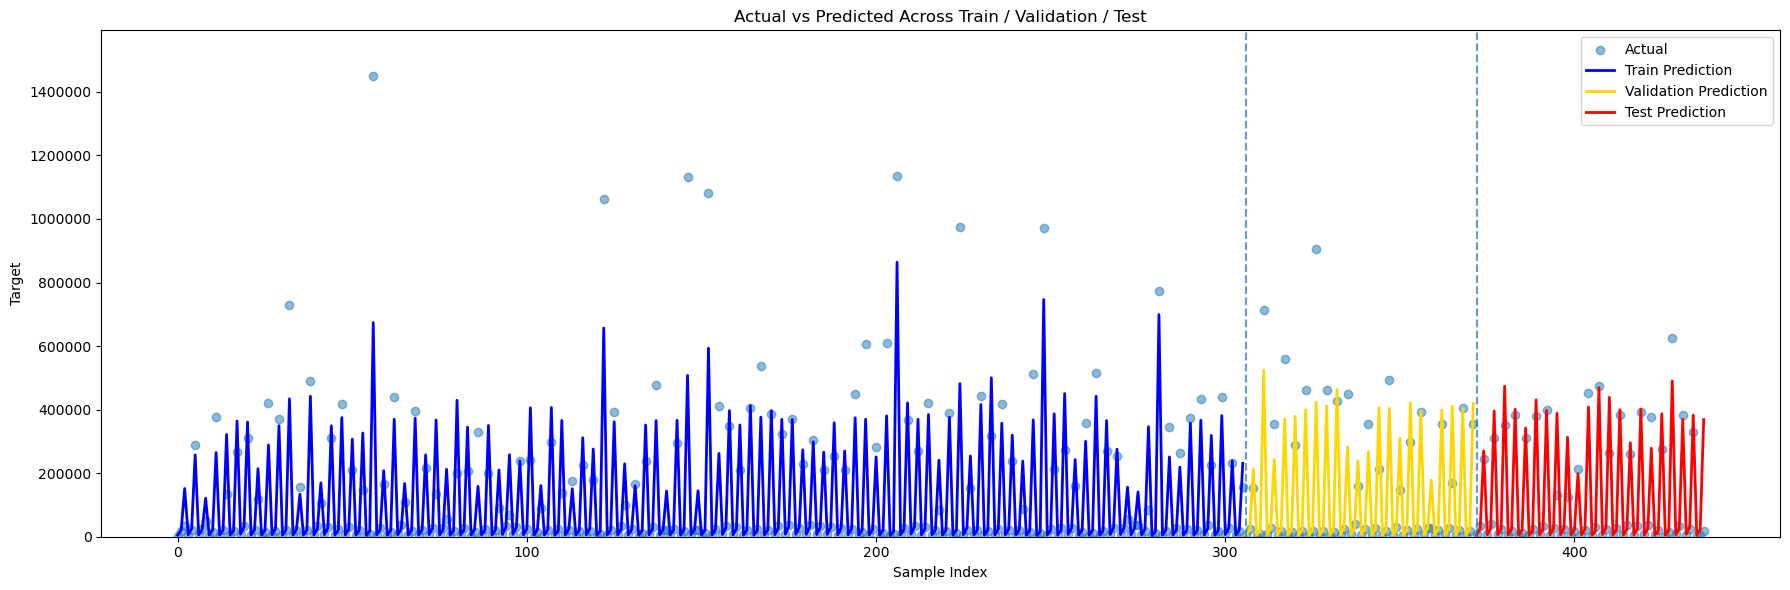

In [49]:
from matplotlib.ticker import ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_actual_vs_predicted(
    model,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test
):
    train_pred = np.ravel(model.predict(X_train))
    val_pred   = np.ravel(model.predict(X_val))
    test_pred  = np.ravel(model.predict(X_test))

    y_train = np.ravel(Y_train)
    y_val   = np.ravel(Y_val)
    y_test  = np.ravel(Y_test)

    print("Train R²:", r2_score(y_train, train_pred))
    print("Val R²:", r2_score(y_val, val_pred))
    print("Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_train, y_val, y_test])

    train_idx = np.arange(len(y_train))
    val_idx   = np.arange(len(y_train), len(y_train) + len(y_val))
    test_idx  = np.arange(len(y_train) + len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    ax.scatter(np.arange(len(y_all)), y_all, alpha=0.5, label="Actual")

    ax.plot(train_idx, train_pred, color="blue", linewidth=2, label="Train Prediction")
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    ax.axvline(len(y_train), linestyle="--", alpha=0.7)
    ax.axvline(len(y_train) + len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), train_pred.max(), val_pred.max(), test_pred.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Target")
    ax.set_title("Actual vs Predicted Across Train / Validation / Test")
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(
    best_model,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test
)

In [52]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

def plot_actual_vs_predicted(
    model,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test,
    target_name
):
    # Get column index
    target_idx = Y_train.columns.get_loc(target_name)

    # Predict only selected target
    train_pred = model.predict(X_train)[:, target_idx]
    val_pred   = model.predict(X_val)[:, target_idx]
    test_pred  = model.predict(X_test)[:, target_idx]

    # Actuals for selected target
    y_train = Y_train[target_name].values
    y_val   = Y_val[target_name].values
    y_test  = Y_test[target_name].values

    print(f"{target_name} Train R²:", r2_score(y_train, train_pred))
    print(f"{target_name} Val R²:", r2_score(y_val, val_pred))
    print(f"{target_name} Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_train, y_val, y_test])

    train_idx = np.arange(len(y_train))
    val_idx   = np.arange(len(y_train), len(y_train) + len(y_val))
    test_idx  = np.arange(len(y_train) + len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    # Actual values
    ax.scatter(np.arange(len(y_all)), y_all, alpha=0.5, label="Actual")

    # Predictions
    ax.plot(train_idx, train_pred, color="blue", linewidth=2, label="Train Prediction")
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    # Split markers
    ax.axvline(len(y_train), linestyle="--", alpha=0.7)
    ax.axvline(len(y_train) + len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), train_pred.max(), val_pred.max(), test_pred.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(target_name)
    ax.set_title(f"Actual vs Predicted — {target_name}")
    ax.legend()

    plt.tight_layout()
    plt.show()

avg_reblogs Train R²: 0.5440619467067942
avg_reblogs Val R²: 0.40323791106501805
avg_reblogs Test R²: -0.07495027087030826


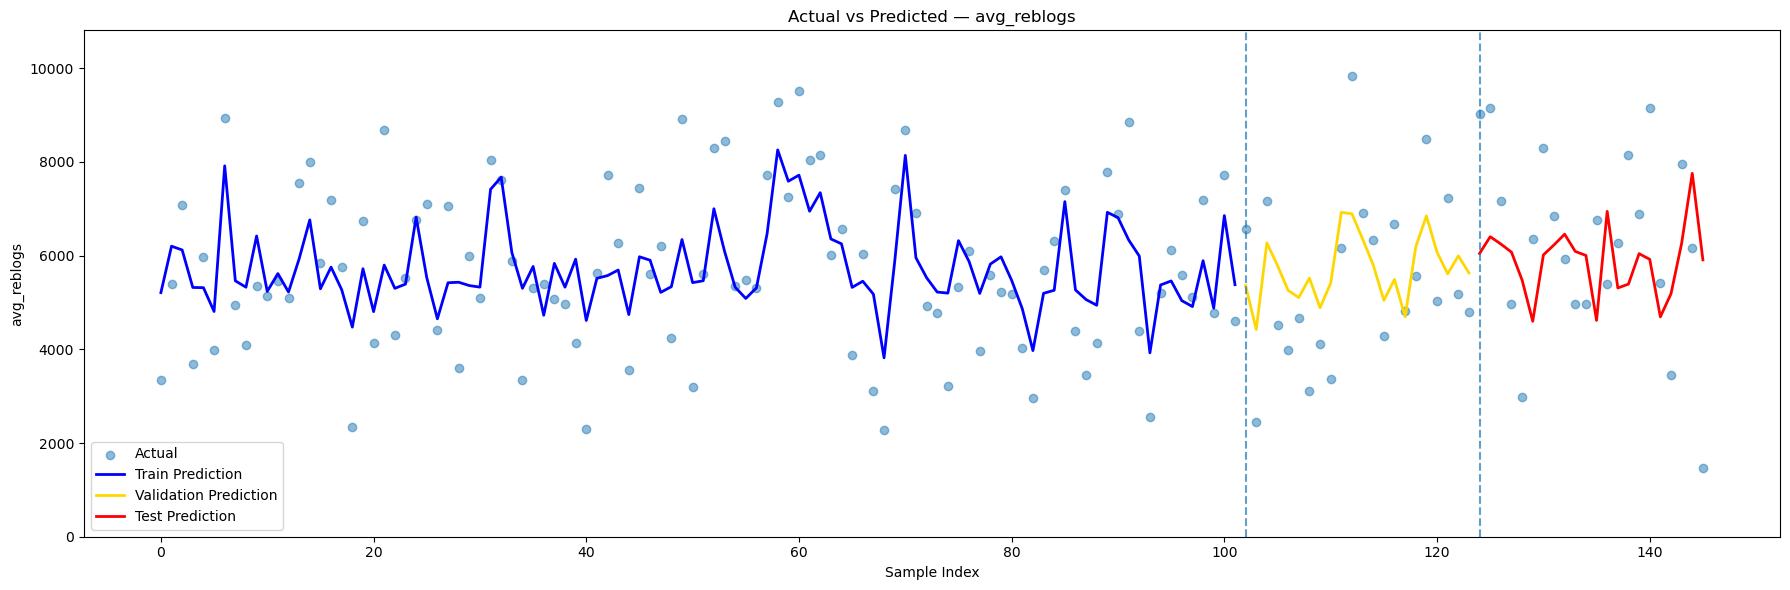

In [53]:
plot_actual_vs_predicted(
    best_model,
    X_train, Y_train,
    X_val, Y_val,
    X_test, Y_test,
    target_name="avg_reblogs"
)

In [64]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def plot_actual_vs_predicted(
    model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name
):
    target_idx = Y_val.columns.get_loc(target_name)

    val_pred  = model.predict(X_val)[:, target_idx]
    test_pred = model.predict(X_test)[:, target_idx]

    y_val  = Y_val[target_name].values
    y_test = Y_test[target_name].values

    print(f"{target_name} Val R²:", r2_score(y_val, val_pred))
    print(f"{target_name} Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_val, y_test])
    pred_all = np.concatenate([val_pred, test_pred])

    df_plot = pd.concat([val, test], axis=0).reset_index(drop=True)

    x = np.arange(len(y_all))

    val_idx  = np.arange(len(y_val))
    test_idx = np.arange(len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    # Actual values
    ax.scatter(x, y_all, alpha=0.5, label="Actual")

    # Predictions
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    # Mark topic_activity_12 == 1
    topic_mask = df_plot["topic_activity_12"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label="topic_activity_12 = 1"
    )
    topic_mask = df_plot["topic_activity_5"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="green",
        linewidths=1.5,
        label="topic_activity_5 = 1"
    )
    topic_mask = df_plot["topic_activity_0"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="blue",
        linewidths=1.5,
        label="topic_activity_0 = 1"
    )
    

    # Split marker between val and test
    ax.axvline(len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), pred_all.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(target_name)
    ax.set_title(f"Actual vs Predicted — {target_name} (Validation + Test)")

    # Secondary axis for sentiment
    ax2 = ax.twinx()
    ax2.plot(
        x,
        df_plot["trump_sentiment_pct_negative"].values,
        color="purple",
        linestyle=":",
        linewidth=2,
        label="Trump Negative Sentiment %"
    )
    ax2.set_ylabel("Trump Negative Sentiment %")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()

total_upvotes Val R²: 0.32520065591843916
total_upvotes Test R²: 0.07927378451132894


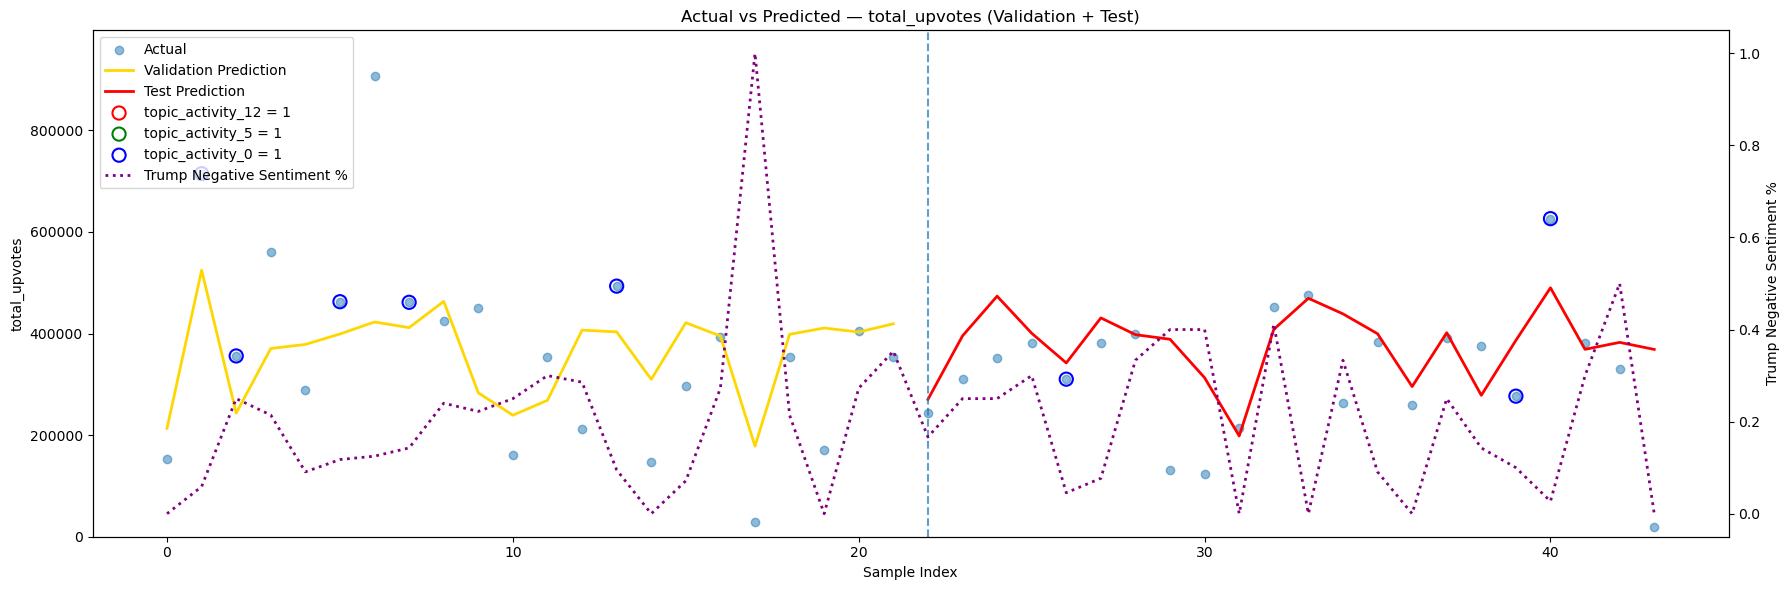

In [65]:
plot_actual_vs_predicted(
    best_model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name="total_upvotes"
)

In [71]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def plot_actual_vs_predicted_with_sentiment(
    model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name
):
    target_idx = Y_val.columns.get_loc(target_name)

    val_pred  = model.predict(X_val)[:, target_idx]
    test_pred = model.predict(X_test)[:, target_idx]

    y_val  = Y_val[target_name].values
    y_test = Y_test[target_name].values

    print(f"{target_name} Val R²:", r2_score(y_val, val_pred))
    print(f"{target_name} Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_val, y_test])
    pred_all = np.concatenate([val_pred, test_pred])

    df_plot = pd.concat([val, test], axis=0).reset_index(drop=True)

    x = np.arange(len(y_all))

    val_idx  = np.arange(len(y_val))
    test_idx = np.arange(len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    # Actual values
    ax.scatter(x, y_all, alpha=0.5, label="Actual")

    # Predictions
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    # Mark topic_activity_12 == 1
    topic_mask = df_plot["topic_activity_12"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="red",
        linewidths=1.5,
        label="topic_activity_12 = 1"
    )
    topic_mask = df_plot["topic_activity_5"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="green",
        linewidths=1.5,
        label="topic_activity_5 = 1"
    )
    topic_mask = df_plot["topic_activity_0"].values == 1
    ax.scatter(
        x[topic_mask],
        y_all[topic_mask],
        s=90,
        facecolors="none",
        edgecolors="blue",
        linewidths=1.5,
        label="topic_activity_0 = 1"
    )

    # Split marker between val and test
    ax.axvline(len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), pred_all.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(target_name)
    ax.set_title(f"Actual vs Predicted — {target_name} (Validation + Test)")

    # Secondary axis for sentiment
    ax2 = ax.twinx()
    ax2.plot(
        x,
        df_plot["trump_sentiment_pct_negative"].values,
        color="purple",
        linestyle=":",
        linewidth=2,
        label="Trump Negative Sentiment %"
    )
    ax2.set_ylabel("Trump Negative Sentiment %")

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()

total_upvotes Val R²: 0.32520065591843916
total_upvotes Test R²: 0.0792737845113285


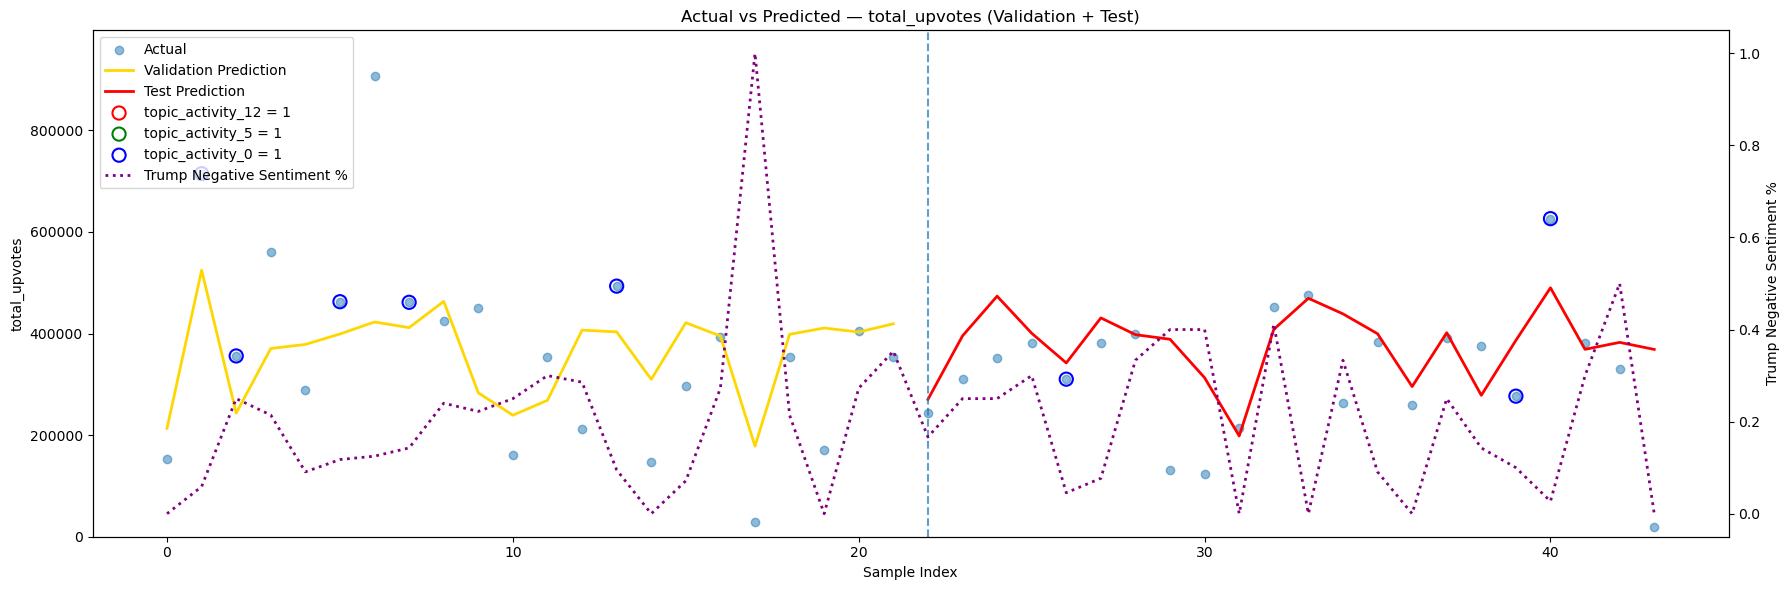

In [72]:
plot_actual_vs_predicted_with_sentiment(
    best_model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name="total_upvotes"
)

In [69]:
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def plot_actual_vs_predicted_with_topics(
    model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name
):
    target_idx = Y_val.columns.get_loc(target_name)

    val_pred  = model.predict(X_val)[:, target_idx]
    test_pred = model.predict(X_test)[:, target_idx]

    y_val  = Y_val[target_name].values
    y_test = Y_test[target_name].values

    print(f"{target_name} Val R²:", r2_score(y_val, val_pred))
    print(f"{target_name} Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_val, y_test])
    pred_all = np.concatenate([val_pred, test_pred])

    df_plot = pd.concat([val, test], axis=0).reset_index(drop=True)

    x = np.arange(len(y_all))

    val_idx  = np.arange(len(y_val))
    test_idx = np.arange(len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    # Actual values
    ax.scatter(x, y_all, alpha=0.5, label="Actual")

    # Predictions
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    # Split marker between val and test
    ax.axvline(len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), pred_all.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(target_name)
    ax.set_title(f"Actual vs Predicted — {target_name} (Validation + Test)")

    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1, labels1, loc="upper left")

    plt.tight_layout()
    plt.show()

total_upvotes Val R²: 0.3252006559184393
total_upvotes Test R²: 0.0792737845113285


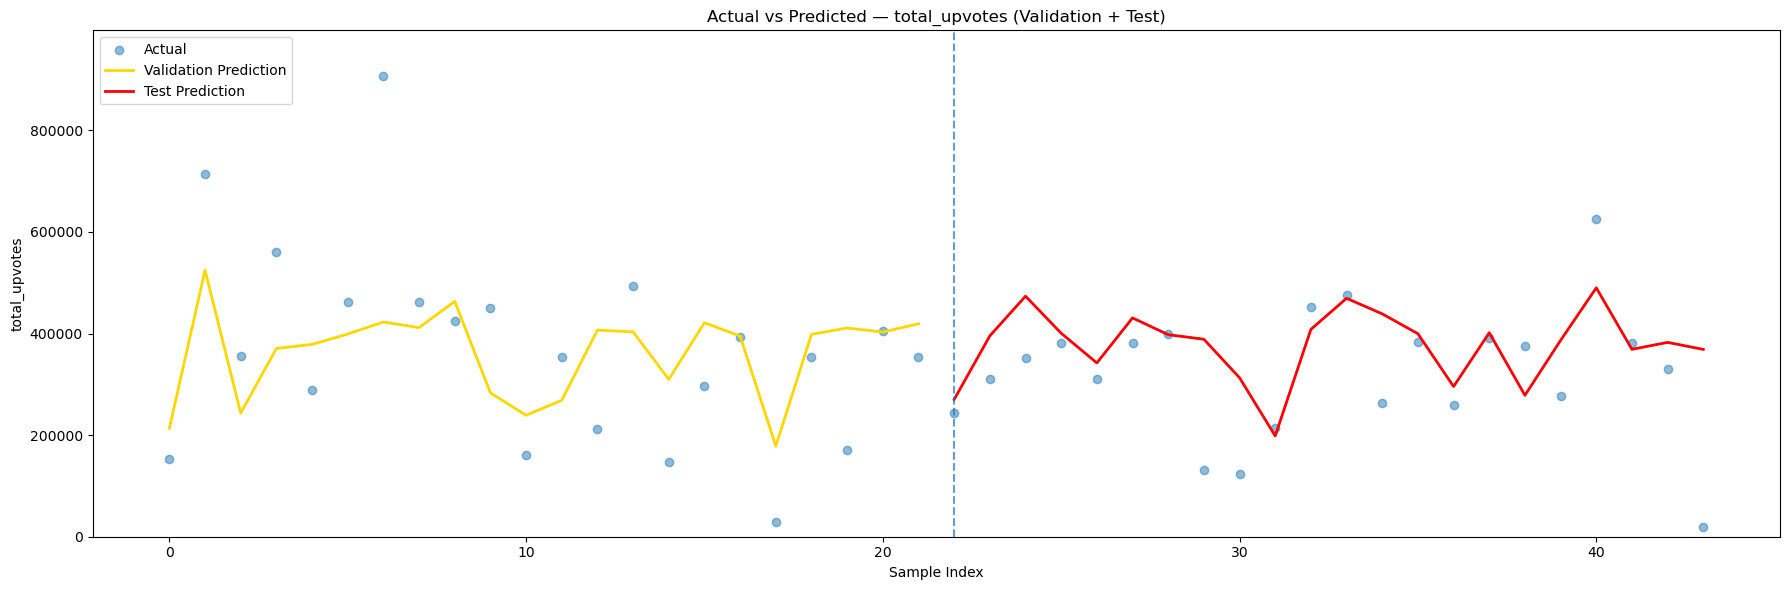

In [70]:
plot_actual_vs_predicted_with_topics(
    best_model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name="total_upvotes"
)

In [ ]:
def plot_actual_vs_predicted_with_topics(
    model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name
):
    target_idx = Y_val.columns.get_loc(target_name)

    val_pred  = model.predict(X_val)[:, target_idx]
    test_pred = model.predict(X_test)[:, target_idx]

    y_val  = Y_val[target_name].values
    y_test = Y_test[target_name].values

    print(f"{target_name} Val R²:", r2_score(y_val, val_pred))
    print(f"{target_name} Test R²:", r2_score(y_test, test_pred))

    y_all = np.concatenate([y_val, y_test])
    pred_all = np.concatenate([val_pred, test_pred])
    df_plot = pd.concat([val, test], axis=0).reset_index(drop=True)

    x = np.arange(len(y_all))
    val_idx  = np.arange(len(y_val))
    test_idx = np.arange(len(y_val), len(y_all))

    fig, ax = plt.subplots(figsize=(18, 6))

    ax.scatter(x, y_all, alpha=0.5, label="Actual")
    ax.plot(val_idx, val_pred, color="gold", linewidth=2, label="Validation Prediction")
    ax.plot(test_idx, test_pred, color="red", linewidth=2, label="Test Prediction")

    # Mark all topics 0–12 with black circles and text labels
    for topic_id in range(13):
        col = f"topic_activity_{topic_id}"
        topic_mask = df_plot[col].values == 1

        ax.scatter(
            x[topic_mask],
            y_all[topic_mask],
            s=90,
            facecolors="none",
            edgecolors="black",
            linewidths=1.5
        )

        for xi, yi in zip(x[topic_mask], y_all[topic_mask]):
            ax.annotate(
                f"Topic {topic_id}",
                xy=(xi, yi),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8,
                color="black"
            )

    ax.axvline(len(y_val), linestyle="--", alpha=0.7)

    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_ylim(0, max(y_all.max(), pred_all.max()) * 1.1)

    ax.set_xlabel("Sample Index")
    ax.set_ylabel(target_name)
    ax.set_title(f"Actual vs Predicted — {target_name} (Validation + Test)")



    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.show()

total_upvotes Val R²: 0.32520065591843916
total_upvotes Test R²: 0.07927378451132894


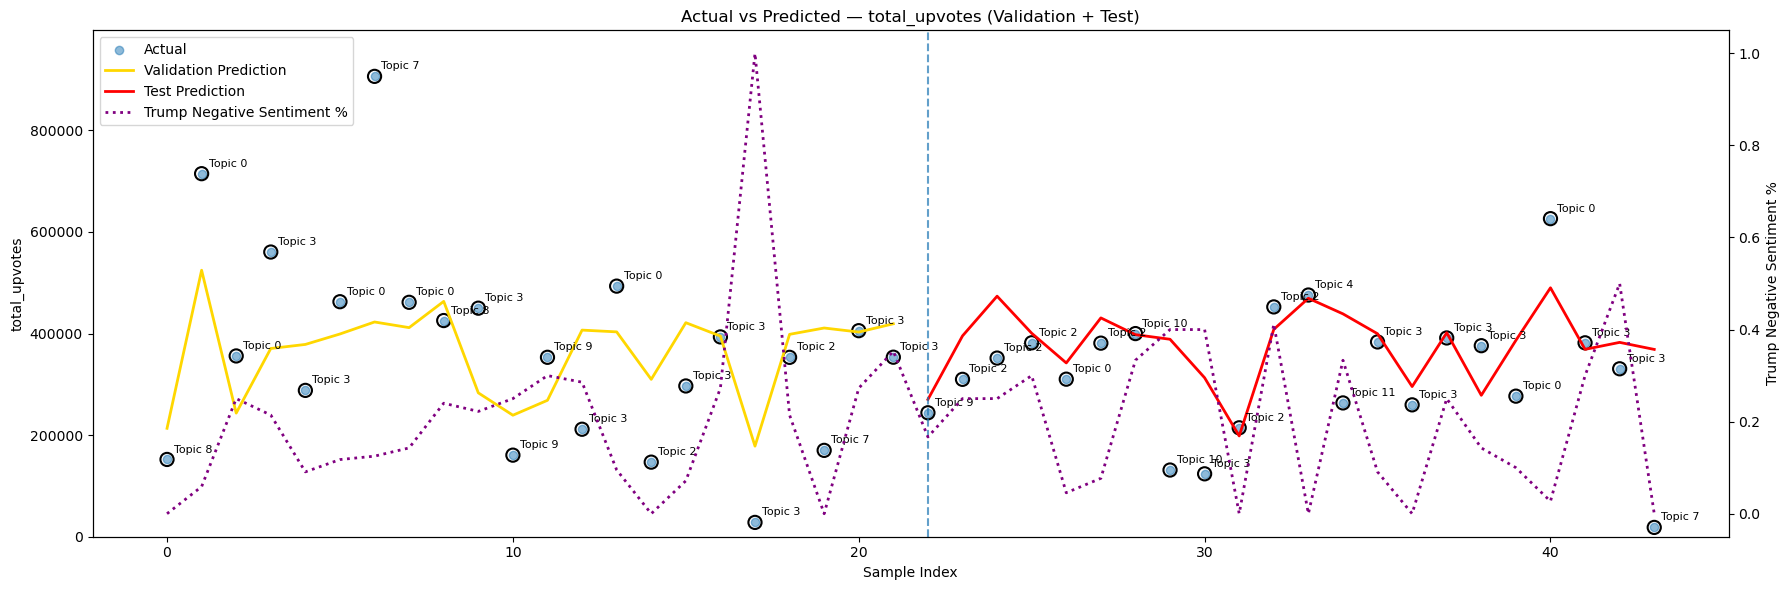

In [76]:
plot_actual_vs_predicted_with_topics(
    best_model,
    X_val, Y_val,
    X_test, Y_test,
    val, test,
    target_name="total_upvotes"
)